# Deteksi Fraud Transaksi Menggunakan Metode Autoencoder

**Mata Kuliah :** Machine Learning

**Disusun Oleh :**
- Nama : Gibran Wicaksono
- NIM : 24260037

---

## Latar Belakang

Fraud atau kecurangan pada transaksi elektronik merupakan salah satu masalah yang sering terjadi pada sistem pembayaran digital. Karena jumlah transaksi normal jauh lebih banyak dibandingkan transaksi fraud, proses deteksi menjadi cukup sulit apabila menggunakan metode klasifikasi biasa.

Pada penelitian ini digunakan metode **Autoencoder**, yaitu salah satu metode pembelajaran unsupervised yang mampu mempelajari pola transaksi normal. Transaksi yang memiliki pola berbeda akan menghasilkan reconstruction error yang tinggi sehingga dapat dikategorikan sebagai transaksi fraud.

In [1]:
!pip install tensorflow pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Library

Pada tahap ini dilakukan import library yang diperlukan untuk proses pengolahan data, pembangunan model Autoencoder, visualisasi data, serta evaluasi model.

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)

## Membaca Dataset

Dataset dibaca menggunakan library Pandas dan disimpan ke dalam DataFrame untuk memudahkan proses analisis dan pengolahan data.

In [3]:
df = pd.read_csv("credit_card_fraud_dataset.csv")

df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


### Informasi Dataset

Menampilkan jumlah data, tipe data setiap fitur, dan jumlah nilai non-null.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


### Statistik Deskriptif

Menampilkan ringkasan statistik dari setiap fitur numerik.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,100000.0,50000.500000,28867.657797,1.00,25000.750,50000.5,75000.2500,100000.00
Amount,100000.0,2497.092666,1442.415999,1.05,1247.955,2496.5,3743.5925,4999.77
MerchantID,100000.0,501.676070,288.715868,1.00,252.000,503.0,753.0000,1000.00
IsFraud,100000.0,0.010000,0.099499,0.00,0.000,0.0,0.0000,1.00


### Missing Value

Mengecek apakah terdapat nilai kosong pada setiap fitur.

In [6]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

## Analisis Awal Dataset

Tahap ini bertujuan untuk mengetahui jumlah transaksi normal dan transaksi fraud yang terdapat dalam dataset.

In [7]:
df['IsFraud'].value_counts()

IsFraud
0    99000
1     1000
Name: count, dtype: int64

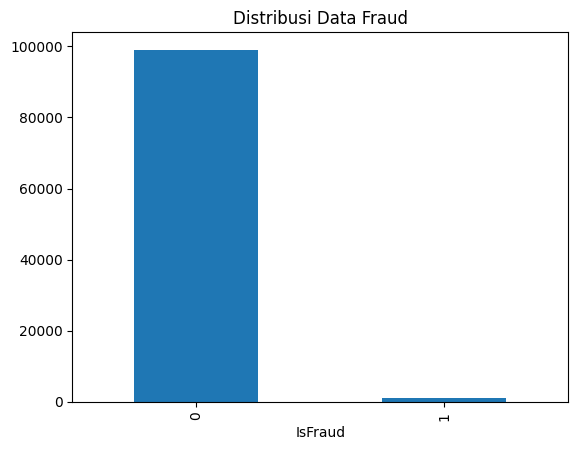

In [8]:
df['IsFraud'].value_counts().plot(
    kind='bar'
)

plt.title("Distribusi Data Fraud")
plt.show()

## Preprocessing Data

Tahap preprocessing dilakukan untuk membersihkan dan menyiapkan data sebelum digunakan dalam proses pelatihan model.

Kolom TransactionID dan TransactionDate tidak digunakan karena tidak memberikan kontribusi langsung terhadap deteksi fraud.

In [9]:
df = df.drop(
    ['TransactionID', 'TransactionDate', 'MerchantID'],
    axis=1
)

df.head()

,Amount,TransactionType,Location,IsFraud
0,4189.27,refund,San Antonio,0
1,2659.71,refund,Dallas,0
2,784.00,purchase,New York,0
3,3514.40,purchase,Philadelphia,0
4,369.07,purchase,Phoenix,0


## Encoding Data Kategorikal

Autoencoder hanya dapat memproses data numerik. Oleh karena itu, atribut kategorikal seperti TransactionType dan Location perlu dikonversi menjadi bentuk numerik menggunakan LabelEncoder.

In [10]:
le_type = LabelEncoder()
ohe_location = OneHotEncoder(sparse_output=False)

df['TransactionType'] = le_type.fit_transform(
    df['TransactionType']
)

location_encoded = ohe_location.fit_transform(
    df[['Location']]
)

location_cols = ohe_location.get_feature_names_out(['Location'])
location_df = pd.DataFrame(
    location_encoded,
    columns=location_cols,
    index=df.index
)

df = pd.concat([df, location_df], axis=1)
df = df.drop('Location', axis=1)

df.head()


,Amount,TransactionType,IsFraud,Location_Chicago,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,4189.27,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2659.71,1,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,784.00,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,3514.40,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,369.07,0,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


## Pemisahan Fitur dan Label

Fitur digunakan sebagai input model, sedangkan label digunakan untuk evaluasi hasil deteksi fraud.

In [11]:
X = df.drop('IsFraud', axis=1)

y = df['IsFraud']


## Split Data Training dan Testing

Dataset dibagi menjadi data training (80%) dan data testing (20%)
menggunakan train_test_split dengan stratifikasi agar proporsi kelas tetap terjaga.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (80000, 12)
X_test shape: (20000, 12)


## Normalisasi Data

Normalisasi dilakukan menggunakan MinMaxScaler agar seluruh fitur berada pada rentang 0 hingga 1.

Hal ini membantu Autoencoder dalam proses pembelajaran.

In [13]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Pemisahan Data Normal

Autoencoder akan dilatih hanya menggunakan transaksi normal.

Tujuannya agar model dapat mempelajari pola transaksi yang wajar dan mengenali transaksi yang menyimpang sebagai anomali.

In [14]:
X_train_normal = X_train_scaled[y_train == 0]

print('X_train_normal shape:', X_train_normal.shape)


X_train_normal shape: (79200, 12)


## Membangun Arsitektur Autoencoder

Autoencoder terdiri dari dua bagian utama:

1. Encoder
   - Mengompresi data menjadi representasi yang lebih kecil.

2. Decoder
   - Merekonstruksi kembali data ke bentuk semula.

Loss function yang digunakan adalah Mean Squared Error (MSE).

In [15]:
input_dim = X_train_normal.shape[1]

input_layer = Input(
    shape=(input_dim,)
)

encoder = Dense(
    8,
    activation='relu'
)(input_layer)

encoder = Dense(
    4,
    activation='relu'
)(encoder)

decoder = Dense(
    8,
    activation='relu'
)(encoder)

decoder = Dense(
    input_dim,
    activation='sigmoid'
)(decoder)

autoencoder = Model(
    inputs=input_layer,
    outputs=decoder
)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │           108 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 288 (1.12 KB)

 Trainable params: 288 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

## Pelatihan Model

Model dilatih menggunakan data transaksi normal selama beberapa epoch.

Tujuan pelatihan adalah meminimalkan nilai reconstruction error.

In [16]:
history = autoencoder.fit(
    X_train_normal,
    X_train_normal,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1465 - val_loss: 0.0971
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0886 - val_loss: 0.0826
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0808 - val_loss: 0.0788
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0745 - val_loss: 0.0693
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0644 - val_loss: 0.0599
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0567 - val_loss: 0.0535
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0506 - val_loss: 0.0478
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0447 - val_loss: 0.0409
Epoch 9/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0376 - val_loss: 0.0342
Epoch 10/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0315 - val_loss: 0.0286
Epoch 11/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0262 - val_loss: 0.0237
Epoch 12/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

## Visualisasi Loss

Grafik loss digunakan untuk melihat perkembangan proses pelatihan model.

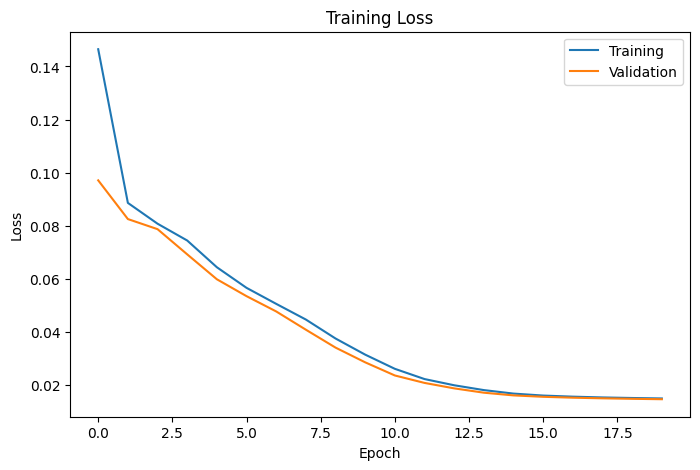

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss']
)

plt.plot(
    history.history['val_loss']
)

plt.title(
    'Training Loss'
)

plt.xlabel(
    'Epoch'
)

plt.ylabel(
    'Loss'
)

plt.legend(
    ['Training','Validation']
)

plt.show()

## Menghitung Reconstruction Error pada Data Uji

Setelah model selesai dilatih, dilakukan proses rekonstruksi terhadap data uji.

Selisih antara data asli dan hasil rekonstruksi dihitung menggunakan Mean Squared Error (MSE).

In [18]:
reconstructions_test = autoencoder.predict(
    X_test_scaled
)

mse_test = np.mean(
    np.power(
        X_test_scaled - reconstructions_test,
        2
    ),
    axis=1
)


625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


## Menentukan Threshold dari Data Training

Threshold ditentukan dari reconstruction error data training (transaksi normal).

Pada penelitian ini digunakan persentil ke-95 dari nilai reconstruction error data training.

In [19]:
reconstructions_train = autoencoder.predict(
    X_train_normal
)

mse_train = np.mean(
    np.power(
        X_train_normal - reconstructions_train,
        2
    ),
    axis=1
)

threshold = np.percentile(
    mse_train,
    95
)

print(
    'Threshold :',
    threshold
)


2475/2475 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
Threshold : 0.08755397707617509


## Visualisasi Distribusi Reconstruction Error

Histogram berikut menunjukkan sebaran reconstruction error (MSE) untuk transaksi normal dan fraud pada data uji.
Garis putus-putus merah menunjukkan threshold.

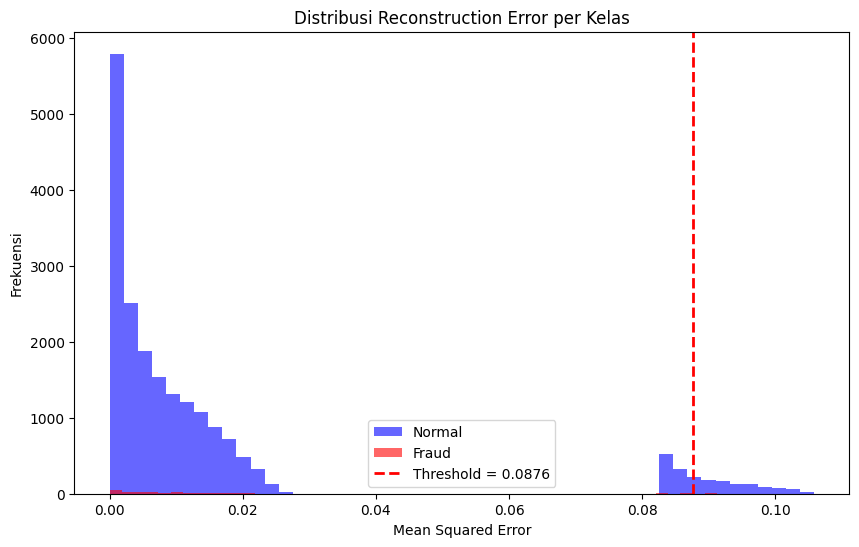

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(mse_test[y_test == 0], bins=50, alpha=0.6, label='Normal', color='blue')
plt.hist(mse_test[y_test == 1], bins=50, alpha=0.6, label='Fraud', color='red')
plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.title('Distribusi Reconstruction Error per Kelas')
plt.xlabel('Mean Squared Error')
plt.ylabel('Frekuensi')
plt.legend()
plt.show()

## Prediksi Fraud pada Data Uji

Jika nilai reconstruction error melebihi threshold, maka transaksi dikategorikan sebagai fraud.

In [21]:
predictions_test = (
    mse_test > threshold
).astype(int)


## Evaluasi Model pada Data Uji

Evaluasi dilakukan menggunakan Confusion Matrix dan Classification Report untuk mengetahui performa model dalam mendeteksi transaksi fraud.

In [22]:
cm = confusion_matrix(
    y_test,
    predictions_test
)

print(cm)


[[18839   961]
 [  194     6]]


In [23]:
print(
    classification_report(
        y_test,
        predictions_test
    )
)


              precision    recall  f1-score   support

           0       0.99      0.95      0.97     19800
           1       0.01      0.03      0.01       200

    accuracy                           0.94     20000
   macro avg       0.50      0.49      0.49     20000
weighted avg       0.98      0.94      0.96     20000



# Kesimpulan

Model Autoencoder berhasil digunakan untuk mendeteksi transaksi fraud berdasarkan reconstruction error.

Autoencoder mempelajari pola transaksi normal dan mengidentifikasi transaksi yang memiliki karakteristik berbeda sebagai anomali.

Semakin besar reconstruction error yang dihasilkan, semakin besar kemungkinan transaksi tersebut merupakan fraud.